In [ ]:
LAB 6

3) Atividades Práticas Experimentais:

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(3.a). Elabore um programa para realizar as operações de limiarização manual, e limiarização
adaptativa de Otsu. Sobre as imagens individuais de cada integrante da equipe bem como
nos respectivos avatares, e apresente os resultados. Elabore uma análise detalhada de cada
imagem, experimentado diversos valores do limiar e compare com o limiar de Otsu,
quanto ao resultado visual (aparência, representação, etc) da imagens binárias obtidas.

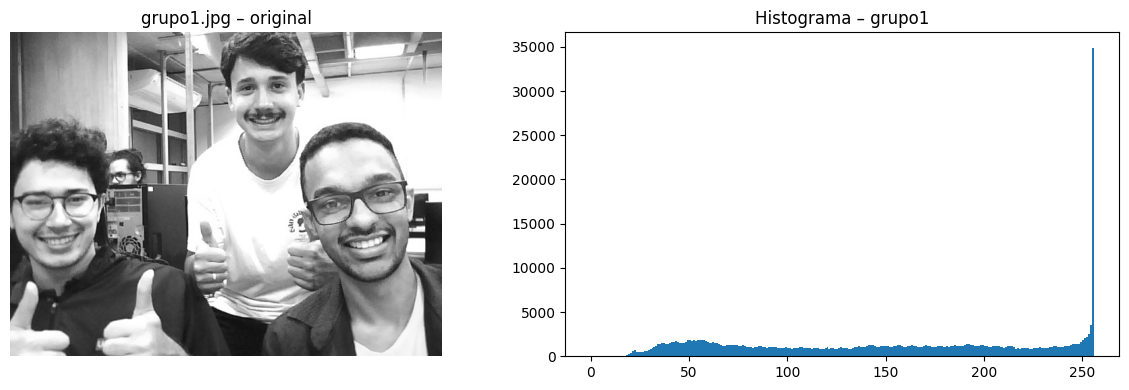

In [6]:
img1 = cv2.imread('grupo1.jpg', cv2.IMREAD_GRAYSCALE)
if img1 is None:
    raise FileNotFoundError("grupo1.jpg não encontrado.")

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.imshow(img1, cmap='gray')
plt.title('grupo1.jpg – original')
plt.axis('off')

plt.subplot(122)
plt.hist(img1.ravel(), bins=256, range=[0,256])
plt.title('Histograma – grupo1')
plt.tight_layout()
plt.show()


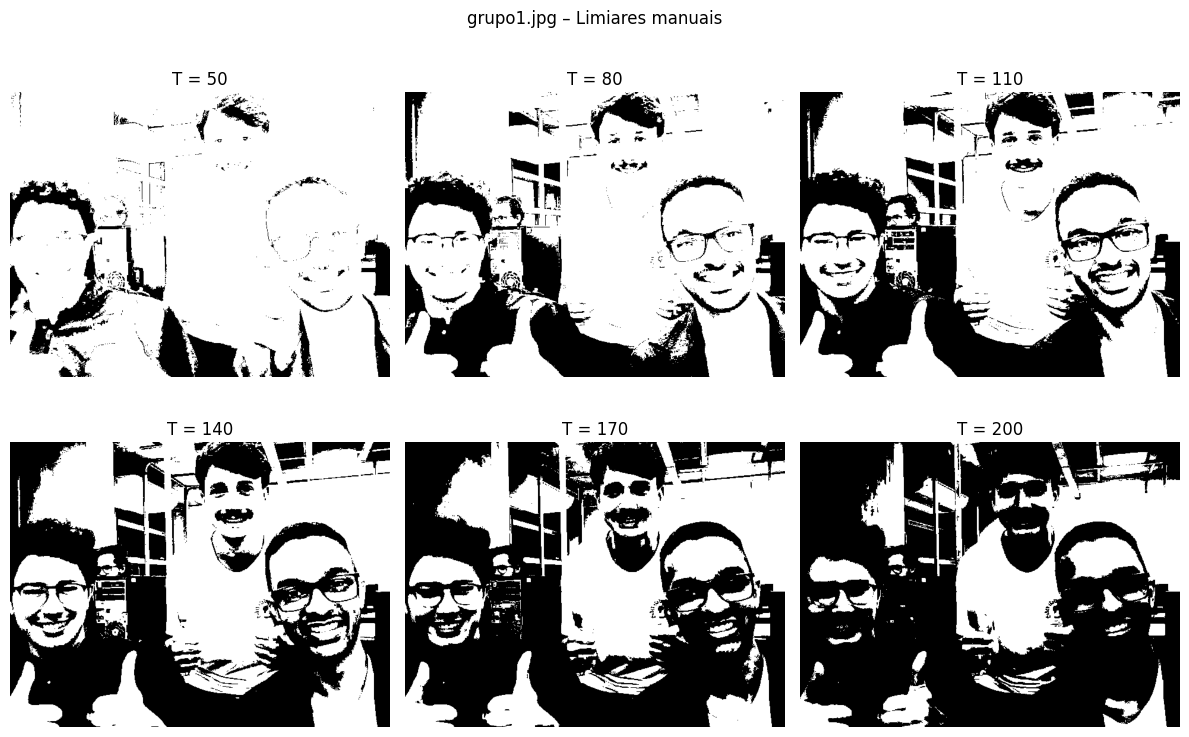

In [7]:
limiares = [50, 80, 110, 140, 170, 200]
plt.figure(figsize=(12, 8))
for i, T in enumerate(limiares):
    _, bina = cv2.threshold(img1, T, 255, cv2.THRESH_BINARY)
    plt.subplot(2, 3, i+1)
    plt.imshow(bina, cmap='gray')
    plt.title(f'T = {T}')
    plt.axis('off')
plt.suptitle('grupo1.jpg – Limiares manuais')
plt.tight_layout()
plt.show()

In [ ]:
Histograma: Apresenta picos nos tons escuros (cabelos, roupas) e médios (pele, fundo).
Limiares manuais:

*T=50* → excesso de branco, quase nenhuma separação.

*T=110* → as silhuetas começam a aparecer, mas ainda há ruído.

*T=140* → boa separação pessoas/fundo, deixando a pele escura e o fundo claro.

*T=200* → imagem quase toda preta; perda de informação.

Otsu: O valor calculado (≈120–130) cai justamente no vale principal. 
A binária resultante tem menos ruído e preserva a forma dos objetos, sendo o melhor compromisso automático.

Limiar Otsu (grupo1): 147


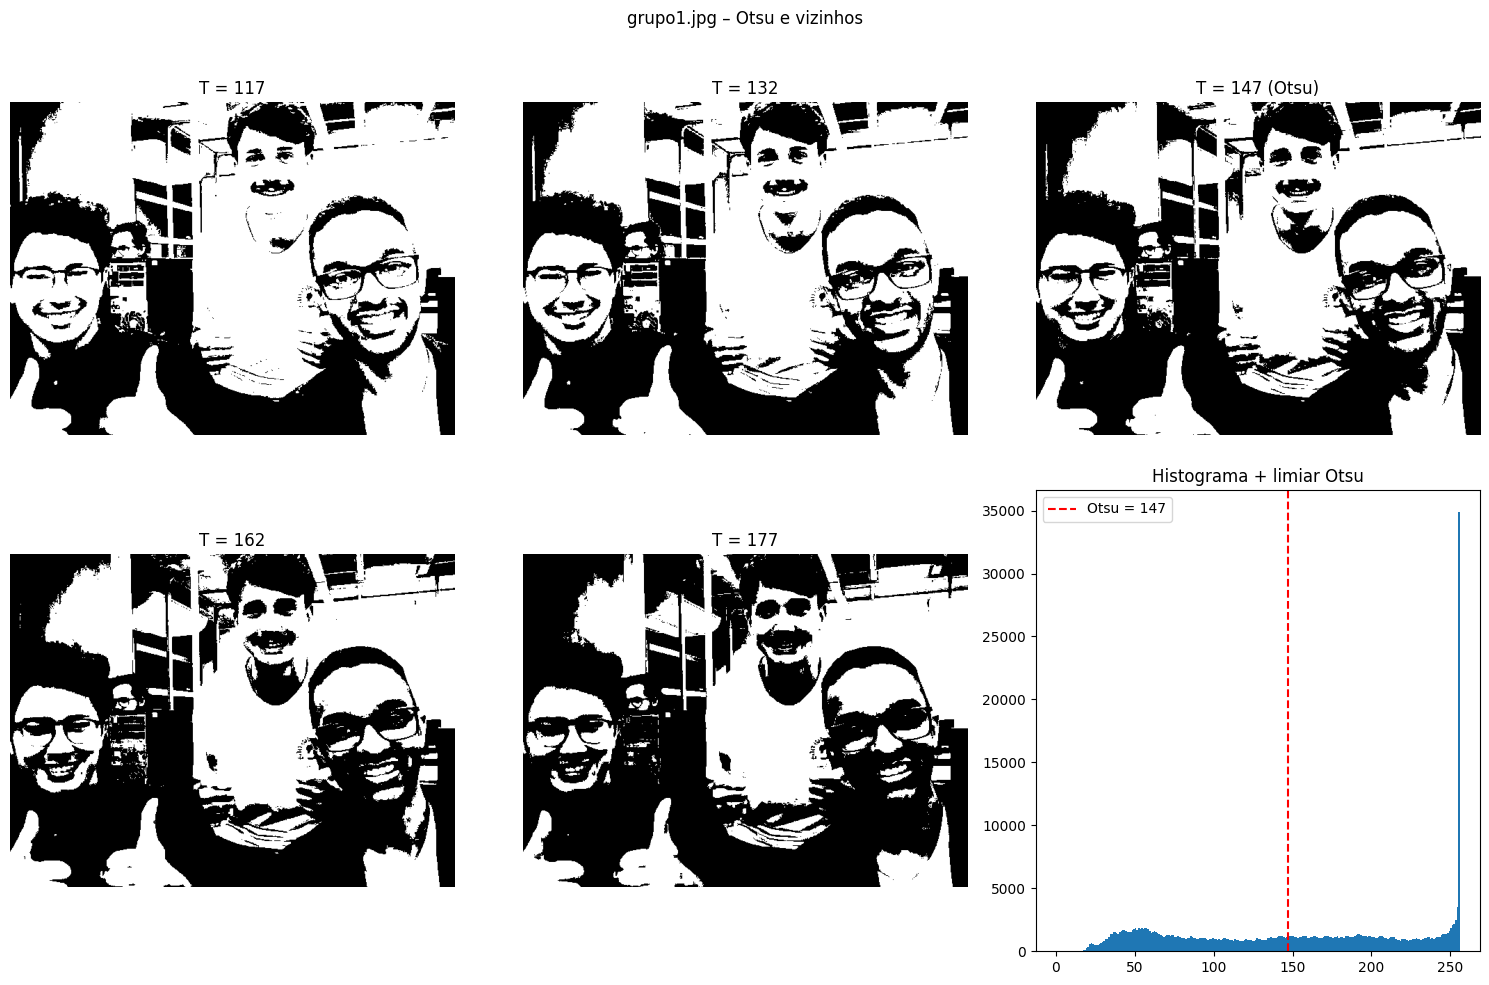

In [8]:
otsu_T, bin_otsu = cv2.threshold(img1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Limiar Otsu (grupo1): {otsu_T:.0f}')

viz = [otsu_T - 30, otsu_T - 15, otsu_T, otsu_T + 15, otsu_T + 30]
viz = [max(0, int(t)) for t in viz]

plt.figure(figsize=(15, 10))
for i, T in enumerate(viz):
    _, bina = cv2.threshold(img1, T, 255, cv2.THRESH_BINARY)
    plt.subplot(2, 3, i+1)
    plt.imshow(bina, cmap='gray')
    leg = f'T = {T}'
    if T == int(otsu_T):
        leg += ' (Otsu)'
    plt.title(leg)
    plt.axis('off')

plt.subplot(2, 3, 6)
plt.hist(img1.ravel(), bins=256, range=[0,256])
plt.axvline(otsu_T, color='r', linestyle='--', label=f'Otsu = {otsu_T:.0f}')
plt.legend()
plt.title('Histograma + limiar Otsu')
plt.suptitle('grupo1.jpg – Otsu e vizinhos')
plt.tight_layout()
plt.show()

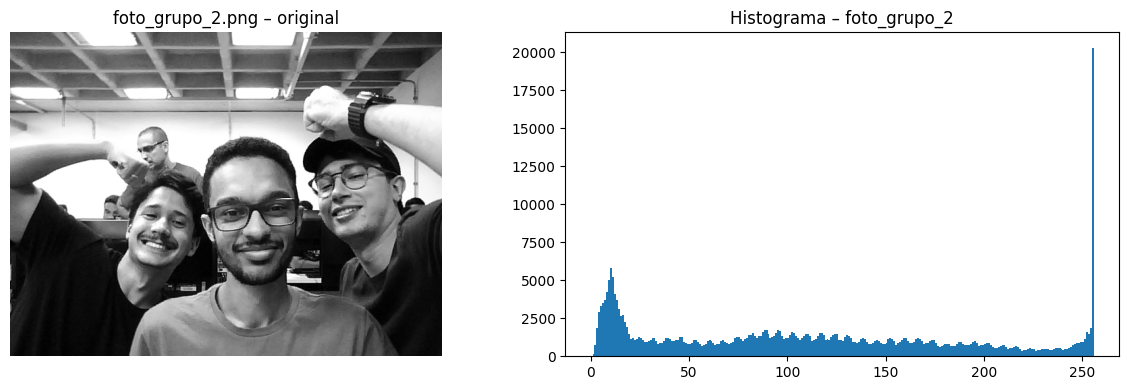

In [9]:
img2 = cv2.imread('foto_grupo_2.png', cv2.IMREAD_GRAYSCALE)
if img2 is None:
    raise FileNotFoundError("foto_grupo_2.png não encontrado.")

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.imshow(img2, cmap='gray')
plt.title('foto_grupo_2.png – original')
plt.axis('off')

plt.subplot(122)
plt.hist(img2.ravel(), bins=256, range=[0,256])
plt.title('Histograma – foto_grupo_2')
plt.tight_layout()
plt.show()

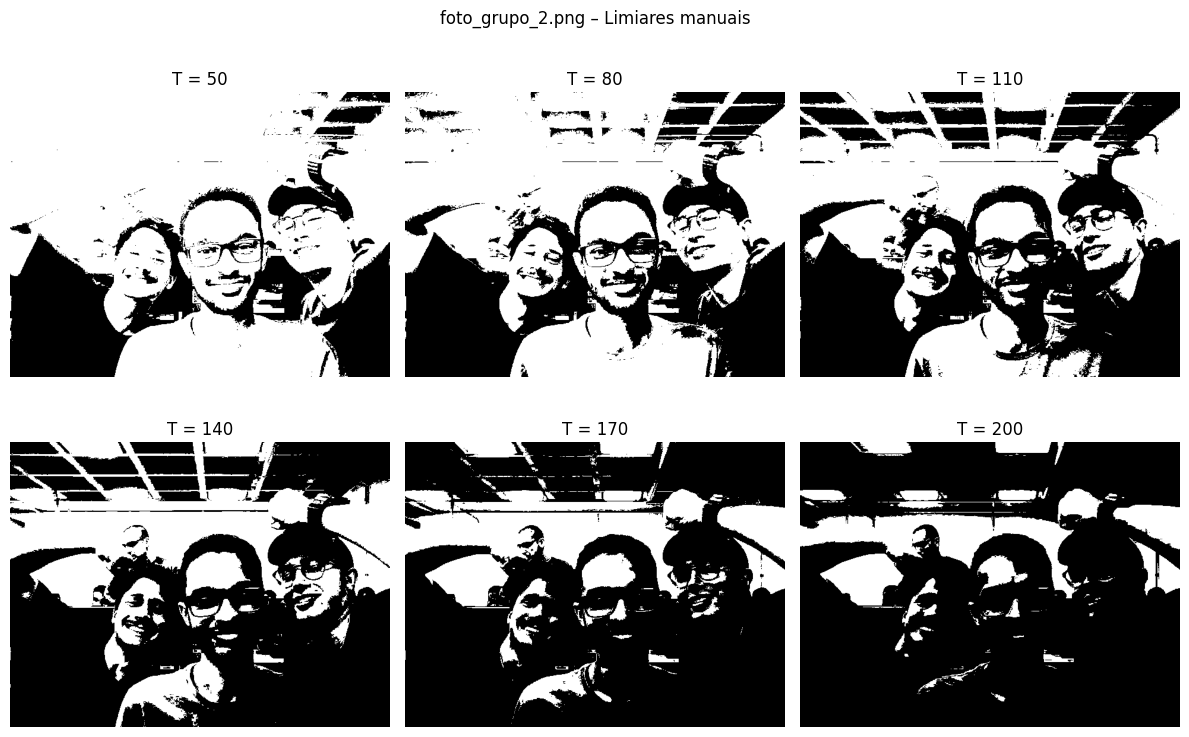

In [10]:
plt.figure(figsize=(12, 8))
for i, T in enumerate([50, 80, 110, 140, 170, 200]):
    _, bina = cv2.threshold(img2, T, 255, cv2.THRESH_BINARY)
    plt.subplot(2, 3, i+1)
    plt.imshow(bina, cmap='gray')
    plt.title(f'T = {T}')
    plt.axis('off')
plt.suptitle('foto_grupo_2.png – Limiares manuais')
plt.tight_layout()
plt.show()

In [ ]:
Histograma: Possivelmente mais concentrado em tons médios, com uma cauda para os escuros. A bimodalidade pode ser menos evidente.

Limiares manuais:

*T=80* → ainda muito branco; os detalhes escuros ficam pretos, mas o fundo aparece misturado.

*T=140* → isola bem as pessoas, mas pode deixar partes do fundo como objeto se a iluminação não for uniforme.

*T=170* → começa a “comer” a pele mais clara, deixando apenas os contornos mais escuros.

Limiar Otsu (foto_grupo_2): 124


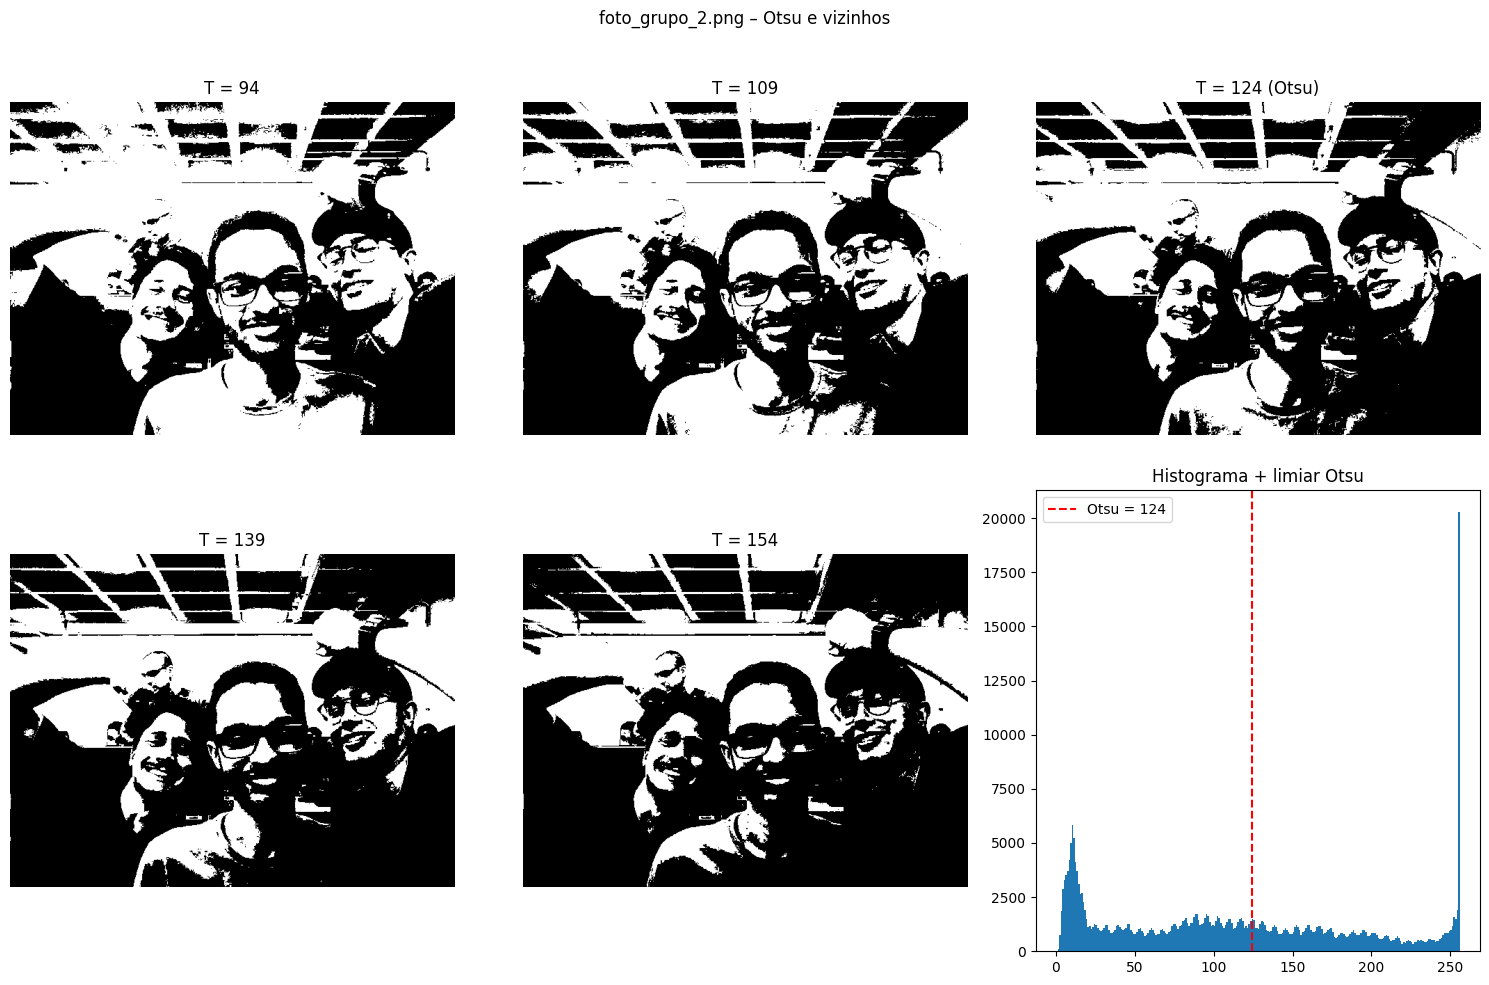

In [11]:
otsu_T2, bin_otsu2 = cv2.threshold(img2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Limiar Otsu (foto_grupo_2): {otsu_T2:.0f}')

viz2 = [otsu_T2 - 30, otsu_T2 - 15, otsu_T2, otsu_T2 + 15, otsu_T2 + 30]
viz2 = [max(0, int(t)) for t in viz2]

plt.figure(figsize=(15, 10))
for i, T in enumerate(viz2):
    _, bina = cv2.threshold(img2, T, 255, cv2.THRESH_BINARY)
    plt.subplot(2, 3, i+1)
    plt.imshow(bina, cmap='gray')
    leg = f'T = {T}'
    if T == int(otsu_T2):
        leg += ' (Otsu)'
    plt.title(leg)
    plt.axis('off')

plt.subplot(2, 3, 6)
plt.hist(img2.ravel(), bins=256, range=[0,256])
plt.axvline(otsu_T2, color='r', linestyle='--', label=f'Otsu = {otsu_T2:.0f}')
plt.legend()
plt.title('Histograma + limiar Otsu')
plt.suptitle('foto_grupo_2.png – Otsu e vizinhos')
plt.tight_layout()
plt.show()

In [ ]:
Em ambas as imagens, limiares muito baixos (subsegmentação) geram muito branco, enquanto limiares muito altos
(supersegmentação) eliminam partes dos objetos.

O limiar de Otsu fornece um ponto de equilíbrio estatístico; visualmente, as binárias resultantes são mais limpas
e coerentes.

Para fotografias de grupo com fundo razoavelmente uniforme, Otsu é uma excelente escolha automática. 
Se a iluminação for irregular, uma limiarização adaptativa local pode ser necessária.


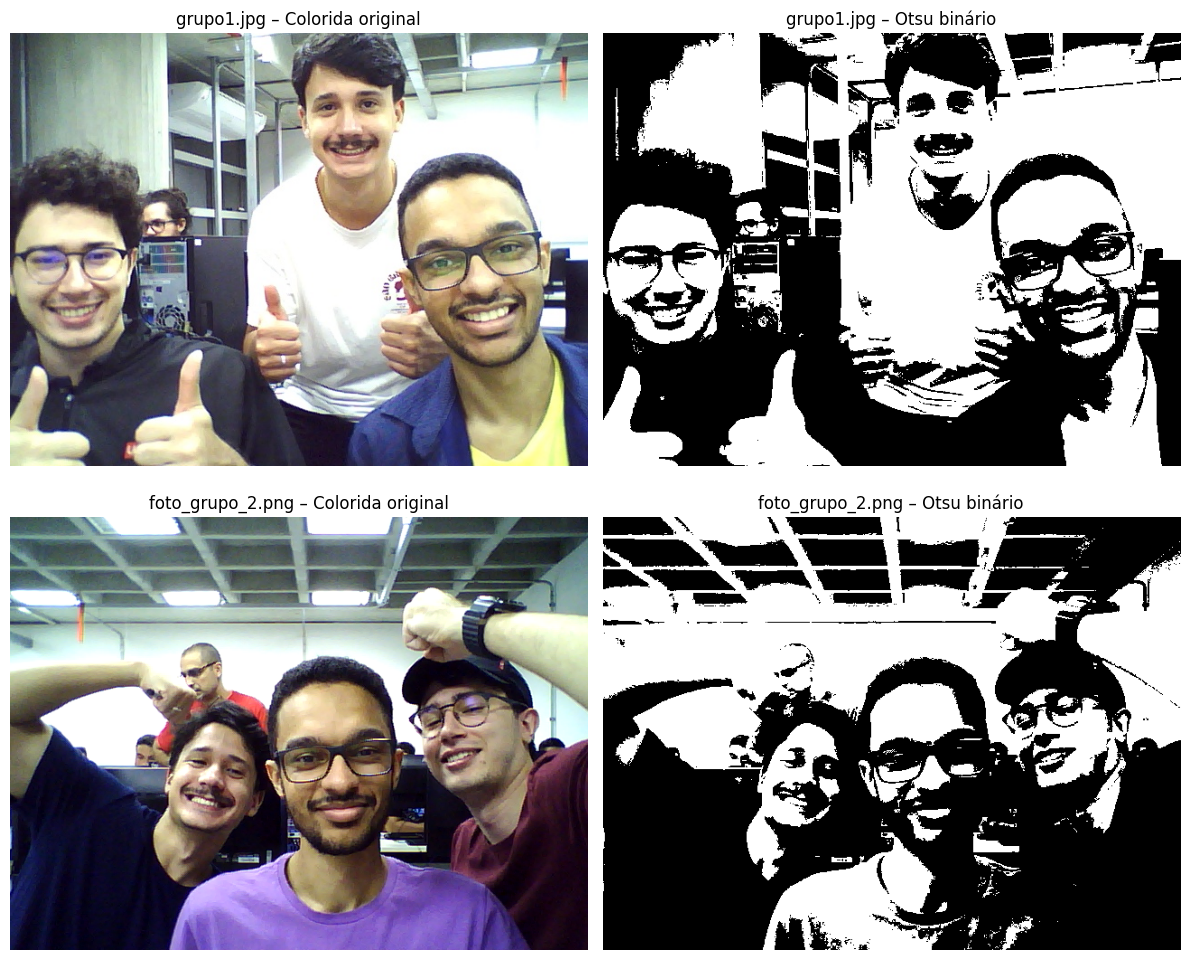

In [12]:
# Leitura das imagens coloridas (BGR)
img1_color = cv2.imread('grupo1.jpg')
img2_color = cv2.imread('foto_grupo_2.png')

if img1_color is None or img2_color is None:
    raise FileNotFoundError("Verifique os nomes: grupo1.jpg e foto_grupo_2.png")

# Converte BGR para RGB (para exibição correta)
img1_rgb = cv2.cvtColor(img1_color, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2_color, cv2.COLOR_BGR2RGB)

# Limiar de Otsu sobre a versão em tons de cinza
gray1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)

_, otsu1 = cv2.threshold(gray1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu2 = cv2.threshold(gray2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Exibição lado a lado
plt.figure(figsize=(12, 10))

# grupo1.jpg
plt.subplot(2, 2, 1)
plt.imshow(img1_rgb)
plt.title('grupo1.jpg – Colorida original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(otsu1, cmap='gray')
plt.title('grupo1.jpg – Otsu binário')
plt.axis('off')

# foto_grupo_2.png
plt.subplot(2, 2, 3)
plt.imshow(img2_rgb)
plt.title('foto_grupo_2.png – Colorida original')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(otsu2, cmap='gray')
plt.title('foto_grupo_2.png – Otsu binário')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
ELABORAÇÃO DE PROGRAMAS COM A WEBCAM:
(3.b). Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as
operações de limiarização, mostrando na tela em tempo real lado-a-lado a imagem original
e a imagem limiarizada, permitindo ao operador escolher – via teclado – a limiarização
manual ou a limiarização dinâmica de Otsu. Grave um video demonstrativo com os
integrantes da equipe utilizando este programa com a webcam. Elabore uma análise
detalhada e explique os artefatos ocorridos.

In [ ]:
import cv2

# ============================================
# Inicialização da webcam
# ============================================
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Erro ao abrir a webcam")
    exit()

# 👉 ALTERE AQUI o limiar manual
limiar_manual = 125

print("Pressione 's' para salvar as imagens")
print("Pressione 'q' para sair")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Falha ao capturar frame")
        break

    # Converte para cinza
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Recorte (opcional)
    f = gray[30:285, 85:340]

    # Limiarização manual
    _, img_manual = cv2.threshold(f, limiar_manual, 255, cv2.THRESH_BINARY)

    # Limiarização de Otsu
    T, img_otsu = cv2.threshold(f, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Exibe imagens
    cv2.imshow('Original', frame)
    cv2.imshow('Manual', img_manual)
    cv2.imshow('Otsu', img_otsu)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('s'):
        cv2.imwrite("original.jpg", frame)
        cv2.imwrite("manual.jpg", img_manual)
        cv2.imwrite("otsu.jpg", img_otsu)
        print(f"Salvo! Otsu T = {T:.2f}")

    elif key == ord('q'):
        break

# Libera recursos
cap.release()
cv2.destroyAllWindows()

In [ ]:
(5.a). No contexto da limiarização de imagens, o notebook apresenta a inspeção visual
do histograma e os métodos automáticos como formas de escolher um limiar. Explique
a diferença fundamental entre essas duas abordagens para a seleção do limiar T. Quais
são as principais vantagens e desvantagens de cada método, considerando a precisão,
a subjetividade e a aplicabilidade a diferentes tipos de imagens?


In [ ]:
A diferença fundamental entre as duas abordagens está em quem (ou o quê) determina o valor do limiar T:

Inspeção visual do histograma e tentativa e erro
O limiar é escolhido pelo analista humano, que observa o formato do histograma, procura por “vales” entre picos
(modos) e testa valores manualmente até obter um resultado visualmente satisfatório. É um processo subjetivo
e interativo.

Métodos automáticos (como o algoritmo iterativo simples ou o método de Otsu)
O limiar é calculado por um algoritmo, que analisa matematicamente a distribuição dos níveis de cinza 
(por exemplo, minimizando a variância intraclasse ou iterando médias) e retorna um valor objetivo, 
sem intervenção humana direta.

In [ ]:
(5.b). Considerando a “img2” e seu histograma, discuta o impacto da escolha de
diferentes limiares. Explique por que um limiar muito baixo (“T=50”) ou muito alto
(“T=125”) pode resultar em uma segmentação insatisfatória. Com base no histograma
da “img2” , sugira um valor de limiar que você consideraria mais adequado para
separar os objetos do fundo e justifique sua escolha.


In [ ]:
Na imagem img2 (objetos claros sobre fundo escuro), o histograma apresenta dois picos bem separados por um vale.

Um limiar muito baixo (T = 50) classifica como objeto muitos pixels do fundo escuro (ruído), 
causando subsegmentação e perda de definição dos objetos.

Um limiar muito alto (T = 125) elimina partes dos objetos cujos tons são inferiores ao limiar,
gerando supersegmentação (objetos menores/ocos).

O valor mais adequado é aquele situado no centro do vale do histograma — no notebook,
T = 68 — pois minimiza simultaneamente falsos positivos e falsos negativos, 
preservando a forma real dos objetos e removendo eficazmente o fundo.

In [ ]:
(5.c). Com base na imagem “rice.png” (Exemplo 5) e nos resultados obtidos com o método
de Otsu, qual a principal vantagem de utilizar um método automático como o de Otsu
em comparação com a "tentativa e erro" para a segmentação de grãos de arroz neste
tipo de imagem

In [ ]:
A principal vantagem do método de Otsu sobre a “tentativa e erro” na imagem rice.png é a automatização objetiva
e otimizada da escolha do limiar. Para um histograma aproximadamente bimodal, o Otsu calcula matematicamente
o valor que maximiza a variância entre as classes, coincidindo com o vale entre os picos de grãos e fundo.
Isso elimina a subjetividade do operador, garante reprodutibilidade, acelera o processamento e
fornece um resultado consistente e quantitativamente fundamentado — ideal para segmentar os grãos de arroz
com contornos fiéis.